In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
# need to conda install lxml if not already installed

# STEP 1: find your storm at this link, make note of its storm_identifier id number 
# (2 letters for basin, 2 digits for storm number, 4 digits for year)
# https://rammb-data.cira.colostate.edu/tc_realtime/season.asp?storm_season=2025

# example: AL052025 - Major Hurricane ERIN

In [2]:
# clean function: 
def get_hurricane_path(storm_id):
    # Read all tables from a URL
    tables = pd.read_html('https://rammb-data.cira.colostate.edu/tc_realtime/storm.asp?storm_identifier=' + storm_id)

    track = tables[1]

    # Set the first row as column headers and remove it from data
    track.columns = track.iloc[0]  # Set first row as column names
    track = track.drop(track.index[0])  # Remove the first row from data
    track.reset_index(drop=True, inplace=True)  # Reset index to start from 0

    track['Synoptic Time'] = pd.to_datetime(track['Synoptic Time'])
    track = track.rename(columns={'Synoptic Time': 'datetime'})
    track = track.sort_values('datetime')
    track['Latitude'] = pd.to_numeric(track['Latitude'])
    track['Longitude'] = pd.to_numeric(track['Longitude'])
    track['Intensity'] = pd.to_numeric(track['Intensity'])

    return track

def plot_hurricane_path(track):
    fig = plt.figure(figsize=(16,7))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines(draw_labels={"left": "y", "bottom": "x"})

    ax.plot(track['Longitude'], track['Latitude'], marker='o')

    plt.show()

In [3]:
track = get_hurricane_path('ep092025')
track

,datetime,Latitude,Longitude,Intensity
19,2025-08-06 18:00:00,13.8,-98.2,35
18,2025-08-07 00:00:00,14.6,-100.0,35
17,2025-08-07 06:00:00,15.4,-102.1,35
16,2025-08-07 12:00:00,17.3,-103.3,40
15,2025-08-07 18:00:00,18.3,-105.0,50
14,2025-08-08 00:00:00,19.3,-106.6,50
13,2025-08-08 06:00:00,20.1,-108.4,50
12,2025-08-08 12:00:00,20.6,-109.6,50
11,2025-08-08 18:00:00,20.3,-110.8,55
10,2025-08-09 00:00:00,20.4,-111.8,55


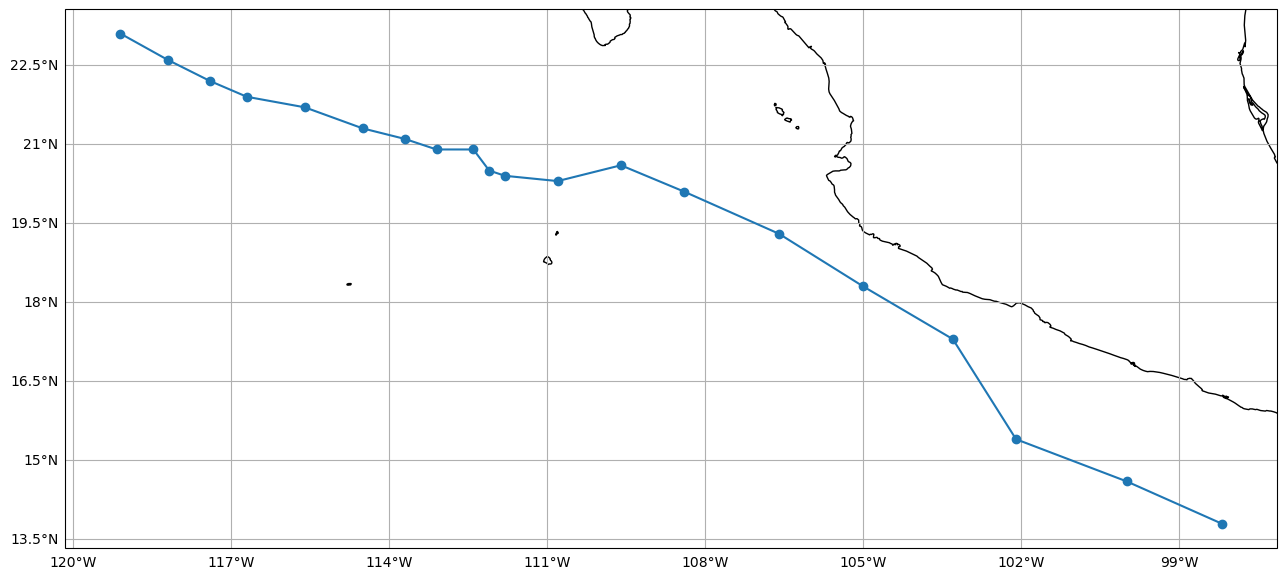

In [4]:
plot_hurricane_path(track)

In [8]:
#storm_id = 'AL052025'
storm_id = 'ep092025'

In [9]:

# Read all tables from a URL
tables = pd.read_html('https://rammb-data.cira.colostate.edu/tc_realtime/storm.asp?storm_identifier=' + storm_id)

In [33]:
track = tables[1]

# Set the first row as column headers and remove it from data
track.columns = track.iloc[0]  # Set first row as column names
track = track.drop(track.index[0])  # Remove the first row from data
track.reset_index(drop=True, inplace=True)  # Reset index to start from 0


In [34]:
track['Synoptic Time'] = pd.to_datetime(track['Synoptic Time'])
track = track.rename(columns={'Synoptic Time': 'datetime'})
track = track.sort_values('datetime')
track['Latitude'] = pd.to_numeric(track['Latitude'])
track['Longitude'] = pd.to_numeric(track['Longitude'])
track['Intensity'] = pd.to_numeric(track['Intensity'])

In [35]:
track

,datetime,Latitude,Longitude,Intensity
19,2025-08-06 18:00:00,13.8,-98.2,35
18,2025-08-07 00:00:00,14.6,-100.0,35
17,2025-08-07 06:00:00,15.4,-102.1,35
16,2025-08-07 12:00:00,17.3,-103.3,40
15,2025-08-07 18:00:00,18.3,-105.0,50
14,2025-08-08 00:00:00,19.3,-106.6,50
13,2025-08-08 06:00:00,20.1,-108.4,50
12,2025-08-08 12:00:00,20.6,-109.6,50
11,2025-08-08 18:00:00,20.3,-110.8,55
10,2025-08-09 00:00:00,20.4,-111.8,55


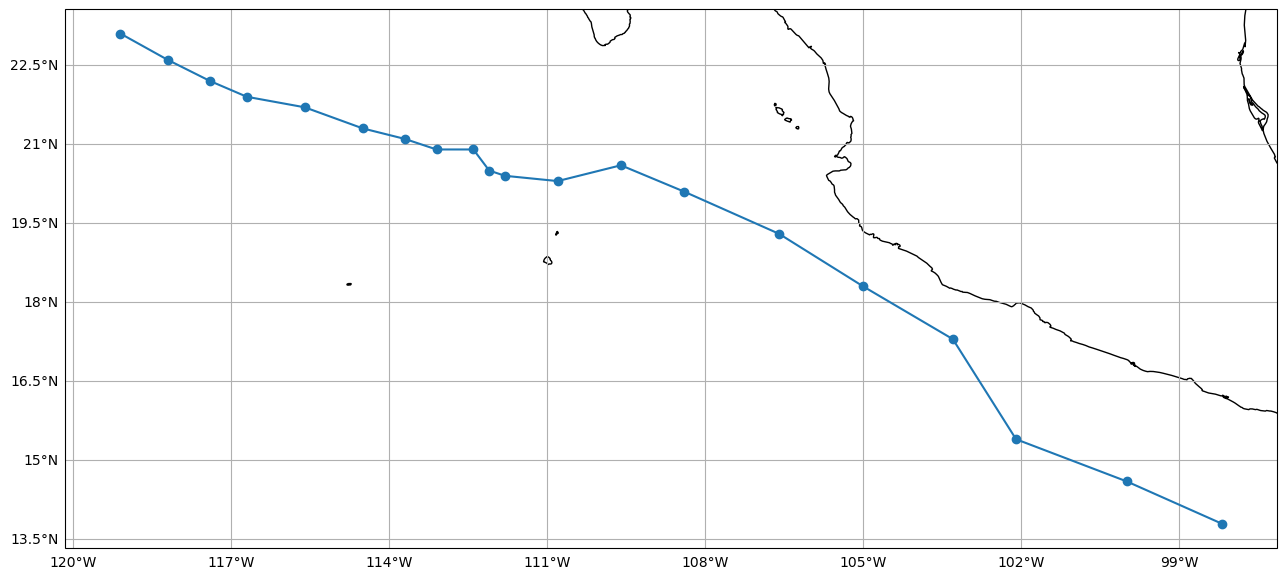

In [40]:
fig = plt.figure(figsize=(16,7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})

ax.plot(track['Longitude'], track['Latitude'], marker='o')
